# <em> Dimensionality Reduction, and Clustering</em>
# <em> with MNIST</em>


***

### Imports

In [2]:
import numpy as np
import scipy as sp
from scipy.integrate import quad
#For plotting
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline

***

#### Introduction to Supervised Learning

This task can serve as an introduction to machine learning, and it will use 1-D data fitting as an example. The power of machine learning is far greater than seen here, but for this example, no special machine learning packages are required, and we will write all of our required code.

The general goal of a supervised learning problem is to develop a model that can predict a label $y \in \mathcal{Y}$ from an input $x \in \mathcal{X}$ using existing sets of data $\{x_i, y_i\}_{i=1,...,n}$. When $\mathcal{Y}$ is discrete, this is called a classification problem, and when $\mathcal{Y}$ is continuous, this is called a regression problem.

We will use the very simple example of one-dimensional, real input and output, equivalently: $\mathcal{X}=\mathcal{Y}=\mathbb{R}$.

The model that is developed is called a *neural network*. The neural network is in general a flexible function $f_\phi: \mathcal{X} \rightarrow \mathcal{Y}$ which has internal parameters $\phi$. These parameters $\phi$ are *trained* in order to best predict the labels $y$ from the input $x$. In general, this network can be extremely complicated, especially when the input data is high-dimensional and/or has meaningful structure, but for this case, our neural network will just be a polynomial function of order $m$, and the model parameters $\phi$ are the coefficients:

$$f_\phi(x) = \phi_0 + \phi_1 x + \phi_2 x^2 + ... + \phi_m x^m.$$

<span style="color:blue"> <i> Write this general neural network function that takes in vectors $\phi$ and $x$. Make sure that this can be evaluated on a vector of x values, giving a vector of the same size. </i></span><br>


In [3]:
# Make a neural network function
def _poly(phi, x):
    '''
    The core model of the neural network. Evaluates a polynomial with coefficients phi at points x.
    '''
    f = []
    exp = [range(0,len(phi))]
    for X in x:
        fx = [X**i for i in exp]
        fp = 0
        for i,p in enumerate(phi):
            fp += p*fx[i]
            f.append(fp)

    return np.array(f)

# Make a neural network function
def poly(phi, x):
    '''
    The core model of the neural network. Evaluates a polynomial with coefficients phi at points x.
    '''
    f = 0
    for i,p in enumerate(phi):
        f += p*(x**i)
    return f


The goal of the training procedure for this neural network is made concrete via a *loss function* $\mathcal{L}(f_\phi(x), y)$. This function is a measure of how poorly the neural network predicts the output labels. In many cases, like this one, the *squared error* is used as a loss function:

$$\mathcal{L}(f_\phi(x), y)=(y-f_\phi(x))^2.$$

The goal of the training procedure is to minimize the expectation value of this loss function over the distribution from which the input data is drawn. We call this expectation value of the loss function the *risk*. The risk represents how bad you expect your model to be at predicting new data, so it is precisely what we want to minimize. For supervised learning, we have a sample of this data with labels of size $n$: $\{x_i, y_i\}_{i=1,...,n}$. We can approximate the risk as the average loss over our sample, which we call the *empirical risk*:

$$R_{emp}=\frac{1}{n}\sum\limits_{i=1}^{n}\mathcal{L}(f_\phi(x_i), y_i).$$

<span style="color:blue"> <i> Load the data and write functions that compute the loss and the empirical risk from parameters $\phi$ and data $x$ with labels $y$. Allow vector input for $x$ and $y$.  </i></span><br>

In [114]:
data = np.loadtxt("./Part4_data.dat")
x = data[0,:]
y = data[1,:]

In [115]:
# Write a loss function
def loss(phi, x, y):
    '''
    Computes the loss function for the polynomial model with coefficients phi on inputs x with labels y.
    Outputs a vector of loss for each input/label pair.
    '''
    Loss = (y - poly(phi, x))**2
    return Loss

# Write an empirical risk function
def risk(phi, x, y):
    '''
    Computes the empirical risk for the polynomial model with coefficients phi on inputs x with labels y.
    '''
    return (1/len(x))*sum(loss(phi,x,y))

 There are many minimization algorithms that can be used to minimize the risk, and we will see others later in this course, but one of the simplest and most well-known minimization algorithms is called gradient descent.

The gradient shows the direction of steepest increase in a function. The opposite direction is the direction of steepest decrease. Gradient descent simply starts at a random point and moves in the opposite direction of the gradient for a large number of iterations. In many situations, this will find the minimum.

In order to do this, we must first write a function to compute the gradient. We can accurately evaluate each component of the gradient using finite differencing:

$$\vec\nabla f = \sum_i \frac{df}{d\phi_i} \hat{\phi_i}$$

$$\frac{df}{d\phi_i}\approx\frac{f(\vec \phi + \delta \cdot \hat{\phi_i})-f(\vec \phi)}{\delta},$$

where $\hat{\phi_i}$ is the $i$th unit vector and $\delta$ is a very small number, we can use $\delta=10^{-4}$.

Now the gradient descent algorithm will begin with an initial set of parameters $\phi^0$ (not to be confused with the first element of $\phi$, $\phi_0$) and subtract a multiple of the gradient to reach the next step:

$$\phi^{i+1}=\phi^i-\lambda\nabla f(\phi^i)$$

$\lambda$ is called the learning rate, and I suggest to use $\lambda=0.5$. This process should iterate for some number of steps, say 1000.

<span style="color:blue"> <i> Write a function that computes a finite differenced gradient given that function $f$, initial input $\phi^0$, and stepsize $\delta$. Then write a function that runs gradient descent and outputs the set of parameters found for each iteration. Make sure it supports a general function $f$ to minimize, initial parameters $\phi^0$, learning rate $\lambda$, finite differencing stepsize $\delta$, and a number of iterations. </i></span><br>

In [123]:
def gradient(f, phi, delta): 
    '''
    Computes the finite difference gradient of the function f at parameters phi...
    '''
    ndim = phi.shape[0]
    grad = np.zeros_like(phi)
    for i in range(ndim):
        deltaphi = np.zeros_like(phi)
        deltaphi[i] = delta
        grad[i] = (f(phi+deltaphi) - f(phi))/delta
    return grad

def gradient_descent(f, phi0, lam, delta, numiter): 
    '''
    Runs the gradient descent algorithm to optimize the function f, parameters include
    learning rate lam, finite difference stepsize delta, for numiter iterations, etc.
    parameters found at each iteration.
    '''
    phis = np.zeros([numiter+1, phi0.shape[0]]) 
    phis[0] = phi0
    
    for i in range(numiter):
        grad = gradient(f, phis[i], delta)
        phis[i+1] = phis[i] - lam*grad 
    return phis

<span style="color:blue"> <i> Now we want to fit our data to a linear function. Run your gradient descent function (with $\phi^0=[0,0]$, $\lambda=0.5$, $\delta=10^{-4}$, and 1000 iterations) on the risk and plot the two parameters in a connected scatter plot that shows the progression of the gradient descent algorithm toward the best fit parameters. Plot the first and last point in separate colors. </i></span><br>
(Note: we may want to use an anonymous/lambda function as the input to our gradient descent function so that y can specify the data $x$ and labels $y$ in the risk.)

In [125]:
# Define inputs to the gradient descent function
phi0 = np.array([0.0,0.0])
lam = 0.5
delta = 1e-4
numiter = 1000

# Run gradient descent function
# Hint: try using an anonymous function with the lambda keyword
phis = gradient_descent(lambda phi: risk(phi, x, y), phi0, lam, delta, numiter)

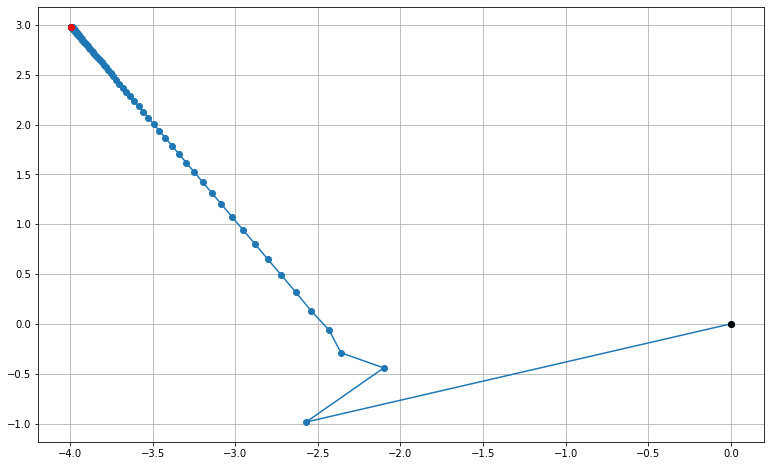

In [128]:
# plot the points
plt.figure(figsize=(13, 8))
plt.plot(phis[:,0], phis[:,1], '-o')

# overplot first and last points
plt.plot(phis[-1,0], phis[-1,1], '-or') 
plt.plot(phis[0,0], phis[0,1], '-ok')
plt.grid()
plt.show()

<span style="color:blue"> <i> Now make a scatter plot of the data and draw the best fit line found by the last iteration of gradient descent. The input data $x$ is entirely within the interval $[0,1]$.</i></span><br>

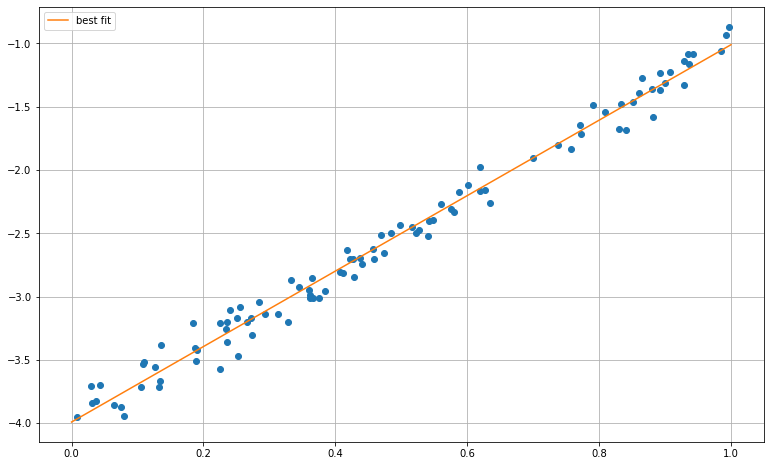

In [131]:
# Generate inputs and outputs using the best parameters
xp = np.linspace(0, 1, 1000)
yp = poly(phis[-1], xp)

# Plot points
plt.figure(figsize=(13, 8))
plt.plot(x, y, 'o')
plt.plot(xp, yp, label = 'best fit')
plt.legend()
plt.grid()
plt.show()

Now let's try doing this again with a new dataset that has more complexity, but still with input $x \in [0,1]$. This time, we'll try increasing the number of parameters.

<span style="color:blue"> <i> Load the new data and train neural networks for polynomials of order 1, 2, 3, and 4 ($m = 2,3,4,$ and $5$ terms, don't forget the constant term). Increase the number of iterations to 10000 (this will take a few seconds to run but it helps to train the more complicated networks). Then plot the training data and the polynomials of these orders. Finally, compute and print the empirical risk for each model on the training data. </i></span><br>

In [132]:
# Load the data
data = np.loadtxt("./Part4_data.dat")
x2 = data[2,:]
y2 = data[3,:]

In [133]:
# Define inputs the gradient descent function
# Hint: phi arrays are different sizes for each polynomial order,
# you can treat them all as the highest order, but with higher coefficients zero
dimarr = np.array([2,3,4,5])
maxdim = 5
lam = 0.5
delta = 1e-4
numiter = 10000
phisarr = np.zeros([4,maxdim,numiter+1])

# Run gradient descent for each network (polynomial order)
for i in range(4): 
    dim = dimarr[i]
    phi0 = np.zeros(int(dim))
    phis = gradient_descent(lambda phi: risk(phi, x2, y2), phi0, lam, delta, numiter) 
    phisarr[i,:dim] = np.transpose(phis)
    
# Extract best fit parameters for each network (polynomial order)
fit_phisarr = phisarr[:,:,-1]

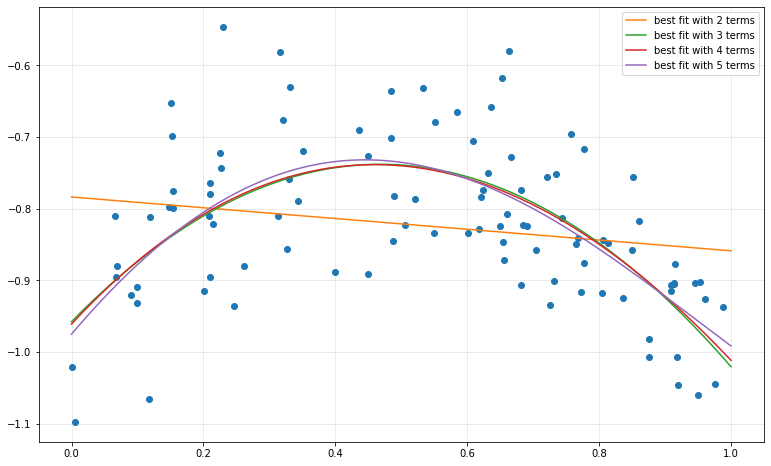

In [134]:
# Plot data and labels in a scatterplot
plt.figure(figsize=(13, 8))
plt.plot(x2, y2, 'o')

# Plot best fits for each polyomial order
xp = np.linspace(0, 1, 1000)
for i in range(4):
    yp_fit = poly(fit_phisarr[i], xp)
    plt.plot(xp, yp_fit, label = 'best fit with ' + str(dimarr[i]) + ' terms')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [135]:
# Compute and print risk for each model on the training data
risks = np.zeros(4)
for i in range(4):
    dim = dimarr[i]
    risks[i] = risk(fit_phisarr[i], x2, y2)
    print('risk on training data for ' + str(dim) + ' terms: ' + str(risks[i]))

risk on training data for 2 terms: 0.01229935500445878
risk on training data for 3 terms: 0.007499273168796524
risk on training data for 4 terms: 0.007456441556646939
risk on training data for 5 terms: 0.007419102474176251


If we have too few parameters in your network, we may not be able to correctly capture the complexity and diversity of the data, and this will lead to inaccurate predictions. But too many parameters can also be problematic. In many cases, the actual data that you might want to predict with your neural network might have a broader scope than the training data. Because of this, we want to be sure not to overfit our data with a model with too many parameters. If we have too many parameters, we will fit more than the underlying signal; we will also fit the noise. This will lead to a poor fit to testing data.

Here we are working with an expanded set of testing data, which is in the expanded interval $[0, 2]$.

<span style="color:blue"> <i> Load the new testing data (given) and plot it with the trained polynomials from the previous part in the expanded interval. Then compute and print the empirical risk for each model on the testing data. </i></span><br>

In [136]:
# Load the data
data = np.loadtxt("./Part4_data.dat")
x3 = data[4,:]
y3 = data[5,:]

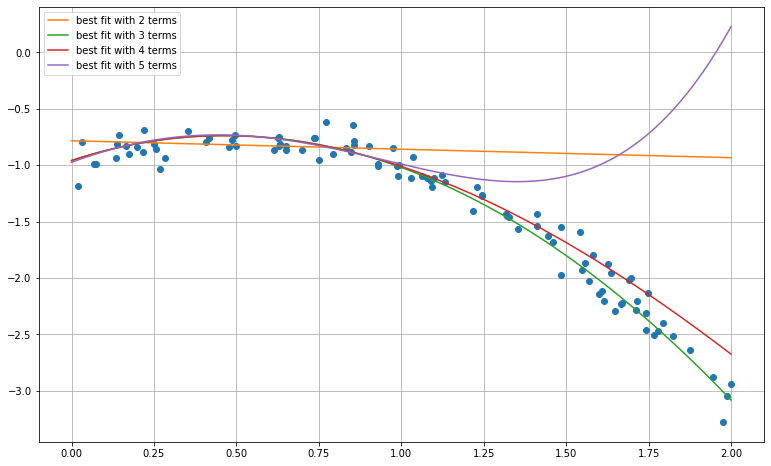

In [138]:
# Plot data and labels in a scatterplot
plt.figure(figsize=(13, 8))
plt.plot(x3, y3, 'o')

# Plot best fits for each polyomial order over the full interval [0, 2]
xp = np.linspace(0, 2, 1000)
for i in range(4):
    yp_fit =  poly(fit_phisarr[i], xp)
    plt.plot(xp, yp_fit, label = 'best fit with ' + str(dimarr[i]) + ' terms')
plt.legend()
plt.grid()
plt.show()

In [141]:
# Compute and print risk for each model on the testing data
risks = np.zeros(4)
for i in range(4):
    dim = dimarr[i]
    risks[i] =  risk(fit_phisarr[i], x3, y3)
    print('risk on testing data for ' + str(dim) + ' terms: ' + str(risks[i]))

risk on testing data for 2 terms: 0.6568373734794162
risk on testing data for 3 terms: 0.01270299283307805
risk on testing data for 4 terms: 0.025488083990060667
risk on testing data for 5 terms: 0.9077035978143723


<span style="color:blue"> <i> Which neural network best predicts the labels for the testing data? </i></span><br>

The Quadratic $(m=3)$ model.

***

####  Unsupervised Learning with MNIST: UMAP + clustering

Yann LeCun and collaborators collected and processed  70,000  handwritten digits to produce what became known as the most widely used database in ML, called MNIST. Here, we are going to work with this dataset. Each handwritten digit comes in a square image, divided into a  28×28  pixel grid. Every pixel can take on  256  nuances of the gray color, interpolating between white and black, and hence each the data point assumes any value in the set  {0,1,…,255}. There are  10  categories, corresponding to the ten digits.

Ever since, the MNIST problem has become an important standard for benchmarking the performance of more sophisticated Machine Learning models. Often times, there are contests for finding a new constellation of hyperparameters and/or model architecture which results in a better accuracy for correctly classifying the digits.

In [8]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784')
X = mnist.data
Y = mnist.target

X = X.to_numpy()
Y = Y.to_numpy()

In [2]:
X.shape, Y.shape

((70000, 784), (70000,))

"$X$" contains information about the given MNIST digits. We have a 28x28 pixel grid, so each image is a vector of length 784; we have 70,000 images (digits), so $X$ is a 70,000x784 matrix. "$Y$" is a label (0-9; the category to which each image belongs) vector of length 70,000.

<span style="color:blue"> <i> Do the following:

(1) Randomly shuffle data (i.e. randomize the order)

  (Note: The label $Y_1$ corresponds to a vector $X_{1j}$, and even after shuffling, $Y_1$ should still correspond to $X_{1j}$.)
  
  
(2) Select 1/3 of the data. (You are free to work with a larger set of the data, but it will take much longer time to train.)


(3) Split data into training and test samples using train_test_split (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Set train_size = 0.8. (80% of $X$ is our training samples.) Print the dimension of training and test samples. </i></span> <br>

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.utils import check_random_state

# shuffle data
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

X,Y = unison_shuffled_copies(X, Y)

# pick training and test data sets
X_train, X_test, Y_train, Y_test = train_test_split(X,Y)

# Select only 1/3 of data
X_train, X_test, Y_train, Y_test = (X_train[:23300], X_test[:23300], Y_train[:23300], Y_test[:23300])

print( np.shape(X_train), np.shape(Y_train) )
print( np.shape(X_test), np.shape(Y_test) )

(23300, 784) (23300,)
(17500, 784) (17500,)


<span style="color:blue"> <i> Choose any five images and show what they look like. Also, print the corresponding label to each image. </i></span> <br>

Hint: each image is a vector of length 784. So reshape it into a 28x28 matrix.

&nbsp; **X_0 = X_train[0]** <br>
&nbsp; **X_0 = X_0.reshape((28, 28))**
  
Then, make a plot using imshow

&nbsp; **plt.imshow(X_0, cmap=plt.cm.gray)**

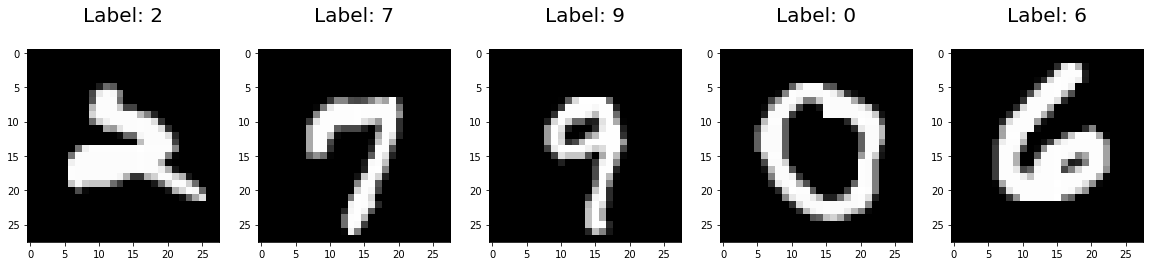

In [150]:
plt.figure(figsize=(20,4))
for index, (image, label) in enumerate(zip(X_train[0:5], Y_train[0:5])):
    plt.subplot(1, 5, index + 1) 
    plt.imshow(np.reshape(image, (28,28)), cmap=plt.cm.gray) 
    plt.title('Label: %i\n' % int(label), fontsize = 20)


The following exercises are taken from the tutorial here: https://umap-learn.readthedocs.io/en/latest/index.html. Please go through them if you want to learn more about the umap package.**UMAP** (Uniform Manifold Approximation and Projection for Dimension Reduction) is a general purpose manifold learning and dimension reduction algorithm. It is designed to be compatible with scikit-learn, making use of the same API and able to be added to sklearn pipelines. If you are already familiar with sklearn you should be able to use UMAP as a drop in replacement for t-SNE and other dimension reduction classes.

In [5]:
import umap

While UMAP can be used for standard unsupervised dimension reduction the algorithm offers significant flexibility allowing it to be extended to perform other tasks, including making use of categorical label information to do supervised dimension reduction, and even metric learning.

Let's use labels ("$Y$") to do supervised learning.

How do we go about coercing UMAP to make use of target labels? If you are familiar with the sklearn API you’ll know that the fit() method (here, you can think of "fitting" as "training.") takes a target parameter y that specifies supervised target information (for example when training a supervised classification model). We can simply pass the UMAP model that target data when fitting and it will make use of it to perform supervised dimension reduction!

First, define your UMAP model:

&nbsp; **model = umap.UMAP()**

Then, using "fit_transform," fit your training sample into an embedded space, with the target array ("Y") for supervised dimension reduction specified.

&nbsp; **embedding_train = model.fit_transform(training X data, training Y label)**

You can use this trained model to transform new data - which is "test data" in this case.

&nbsp; **embedding_test = model.transform(test X data)**

By default, data has reduced down to 2 dimensions. (i.e. embedding_test will have dimensions = (# of test data, 2) - it is an array with test samples, but with 2 feature columns. Each row of the array is a 2-dimensional representation of the corresponding digit.) Thus we can plot the embedding as a standard scatterplot and color by the target array (since it applies to the transformed data which is in the same order as the original).

&nbsp; **plt.scatter(embedding[:, 0], embedding[:, 1], ...)**

<span style="color:blue"> <i> Do the supervised learning and create scatterplots for both training and test data. Color data points according to the corresponding target array $Y$. Make sure to label all 10 classes. Are they cleanly separated?</i></span> <br>


In [42]:
import seaborn as sns

# supervised mode
reducer_s = umap.UMAP()
embedding_s0 = reducer_s.fit_transform(X_train, Y_train) 
embedding_s1 = reducer_s.transform(X_test) 
sns.set(context="paper", style="white")


classes = [ '0',
            '1',
            '2',
            '3',
            '4',
            '5',
            '6',
            '7',
            '8',
            '9']

In [43]:
embedding_s0.shape

(23300, 2)

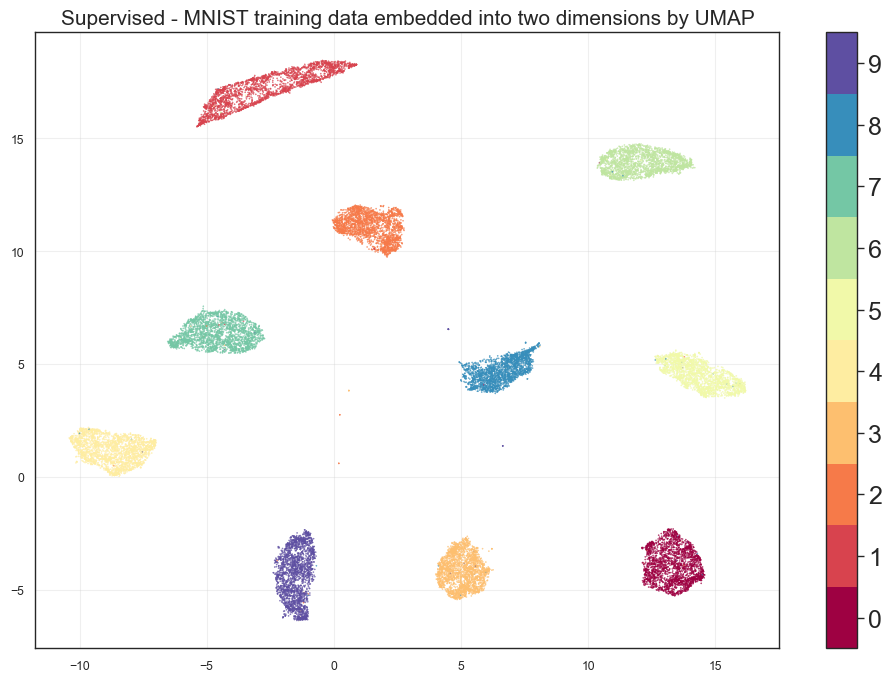

In [24]:
# Plot
fig, ax = plt.subplots(figsize=(12, 8)) 
color = Y_train.astype(int) 
plt.scatter(embedding_s0[:, 0], embedding_s0[:, 1], c=color, cmap="Spectral", s=0.1)
plt.title("Supervised - MNIST training data embedded into two dimensions by UMAP", fontsize=15)

cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.ax.tick_params(labelsize=18)
cbar.set_ticklabels(classes)
plt.grid(alpha=0.3)
plt.show()

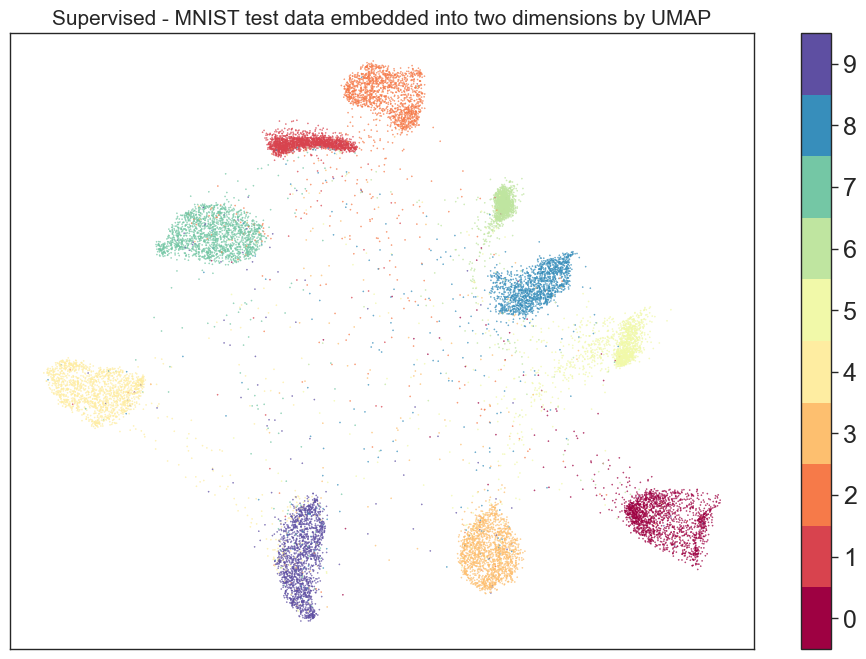

In [38]:
fig, ax = plt.subplots(figsize=(12, 8)) 
color = Y_test.astype(int)
plt.scatter(embedding_s1[:, 0], embedding_s1[:, 1], c=color, cmap="Spectral", s=0.1 )
plt.setp(ax, xticks=[], yticks=[])
plt.title("Supervised - MNIST test data embedded into two dimensions by UMAP", fontsize=15)
cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.ax.tick_params(labelsize=18)
cbar.set_ticklabels(classes)
plt.grid(alpha=0.3)
plt.show()

UMAP has several hyperparameters that can have a significant impact on the resulting embedding: n_neighbors, min_dist, n_components, and metric. (https://umap-learn.readthedocs.io/en/latest/parameters.html)

Each of these parameters has a distinct effect, and we will look at n_neighbors and n_components.

**n_neighbors** controls how UMAP balances local versus global structure in the data. It does this by constraining the size of the local neighborhood UMAP will look at when attempting to learn the manifold structure of the data. This means that low values of n_neighbors will force UMAP to concentrate on very local structure (potentially to the detriment of the big picture), while large values will push UMAP to look at larger neighborhoods of each point when estimating the manifold structure of the data, losing fine detail structure for the sake of getting the broader of the data.

We can see that in practice by fitting our dataset with UMAP using a range of n_neighbors values. The default value of n_neighbors for UMAP (as used above) is 15.

<span style="color:blue"> <i> Choose n_neighbors=2 and n_neighbors=200. What happens as we increase n_neighbors? </i></span> <br>


In [94]:
reducer_s = umap.UMAP(n_components=2, n_neighbors=2, random_state=42) 
embedding_s0 = reducer_s.fit_transform(X_train, Y_train)

reducer_s1 = umap.UMAP(n_components=2, n_neighbors=200, random_state=42) 
embedding_s01 = reducer_s1.fit_transform(X_train, Y_train)

import warnings
warnings.filterwarnings('ignore')

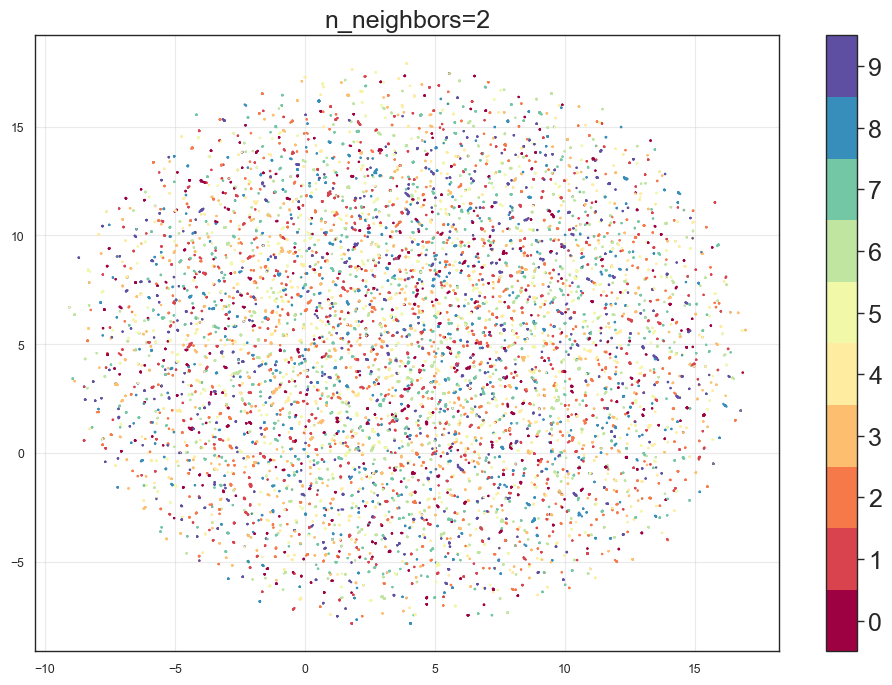

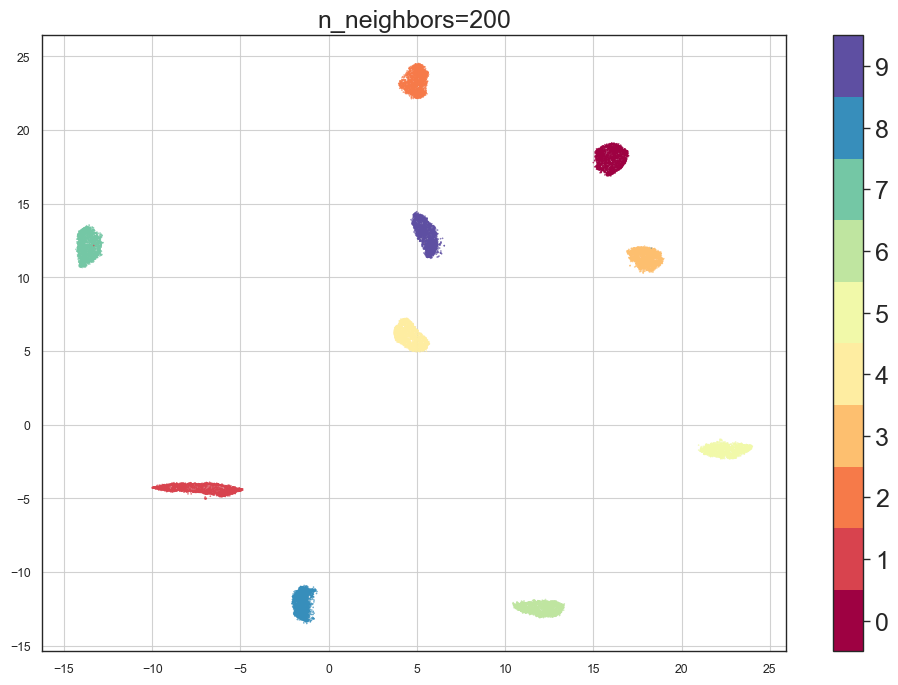

In [100]:
fig, ax = plt.subplots(figsize=(12, 8)) 
color = Y_train.astype(int) 
plt.scatter(embedding_s0[:, 0], embedding_s0[:, 1], c=color, cmap="Spectral", s=0.8 )
# plt.setp(ax, xticks=[], yticks=[]) 
plt.title("n_neighbors=2", fontsize=18)
cbar = plt.colorbar(boundaries=np.arange(11)-0.5) 
cbar.set_ticks(np.arange(10)) 
cbar.ax.tick_params(labelsize=18) 
cbar.set_ticklabels(classes)
plt.grid(alpha=0.4)
plt.show()

fig, ax = plt.subplots(figsize=(12, 8)) 
color = Y_train.astype(int) 
plt.scatter(embedding_s01[:, 0], embedding_s01[:, 1], c=color, cmap="Spectral", s=0.1 )
plt.title("n_neighbors=200", fontsize=18)
cbar = plt.colorbar(boundaries=np.arange(11)-0.5) 
cbar.set_ticks(np.arange(10)) 
cbar.ax.tick_params(labelsize=18) 
cbar.set_ticklabels(classes)
plt.grid(alpha=0.9)
plt.show()

With a value of n_neighbors=2 we see that UMAP merely glues together small chains, but due to the narrow/local view, fails to see how those connect together. It also leaves many different components (and even singleton points). This represents the fact that from a fine detail point of view the data is very disconnected and scattered throughout the space.

As n_neighbors is increased UMAP manages to see more of the overall structure of the data, gluing more components together, and better coverying the broader structure of the data. By the stage of n_neighbors=20 we have a fairly good overall view of the data showing how the various colors interelate to each other over the whole dataset.

As n_neighbors increases further more and more focus in placed on the overall structure of the data. This results in, with n_neighbors=200 a plot where the overall structure is well captured, but at the loss of some of the finer local sturcture.

***

As is standard for many scikit-learn dimension reduction algorithms UMAP provides a **n_components** parameter option that allows the user to determine the dimensionality of the reduced dimension space we will be embedding the data into. Unlike some other visualisation algorithms such as t-SNE UMAP scales well in embedding dimension, so you can use it for more than just visualisation in 2- or 3-dimensions.

So that we can see the effects of the parameter, we will only be looking at 1-dimensional and 3-dimensional embeddings, which we have some hope of visualizing.

First of all we will set n_components to 1, forcing UMAP to embed the data in a line. For visualisation purposes we will randomly distribute the data on the y-axis to provide some separation between points.

<span style="color:blue"> <i> Choose n_components=1 and n_components=3. Observe the scatterplots. </i></span> <br>

In [39]:
from mpl_toolkits.mplot3d import Axes3D

In [45]:
reducer_s = umap.UMAP(n_components=1)
embedding_s0 = reducer_s.fit_transform(X_train, Y_train)
reducer_s1 = umap.UMAP(n_components=3)
embedding_s01 = reducer_s1.fit_transform(X_train, Y_train)

warnings.filterwarnings('ignore')

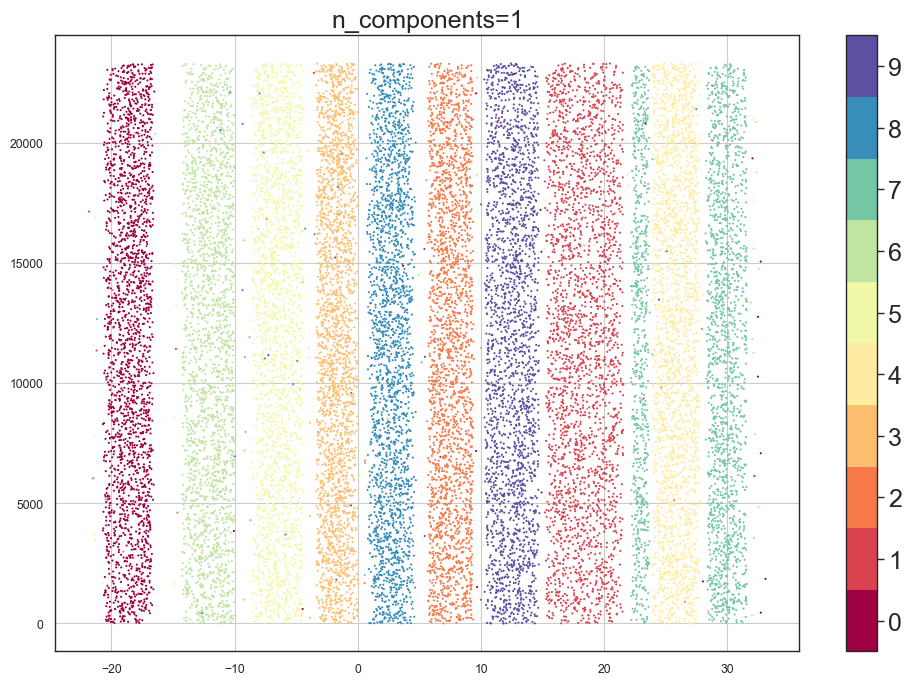

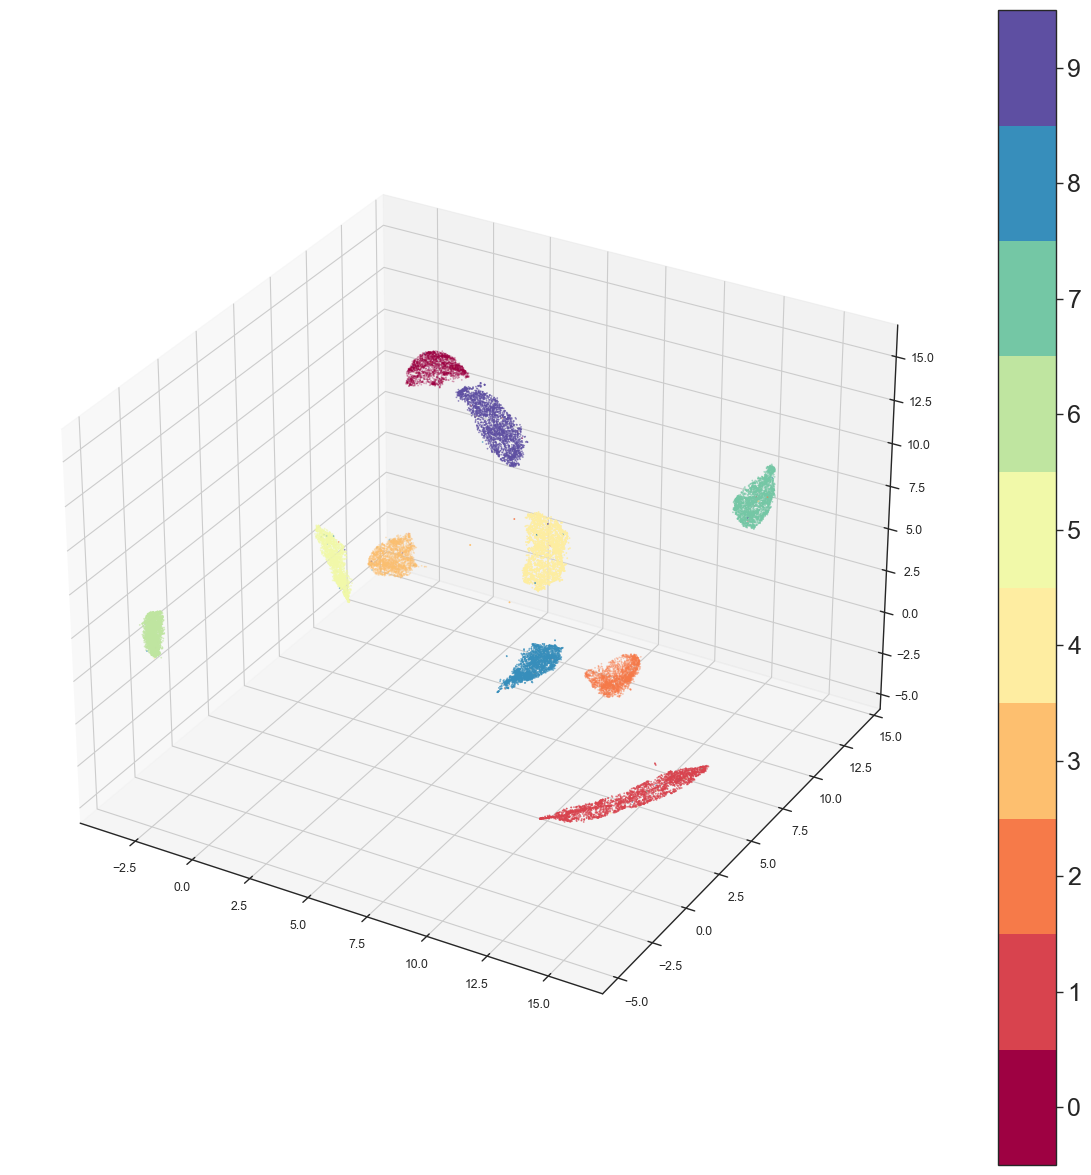

In [88]:
fig, ax = plt.subplots(figsize=(12, 8))

color = Y_train.astype(int) 
plt.scatter(embedding_s0[:, 0], range(len(embedding_s0)), c=color, cmap="Spectral", s=0.5 )
ax.grid(True)
cbar.set_ticks(np.arange(10))
plt.title("n_components=1", fontsize=18)
cbar = plt.colorbar(boundaries=np.arange(11)-0.5) 
cbar.set_ticks(np.arange(10)) 
cbar.ax.tick_params(labelsize=18) 
cbar.set_ticklabels(classes)

plt.show()



fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.grid(True)
cbar.set_ticks(np.arange(10))

sc = ax.scatter(
    embedding_s01[:, 0],
    embedding_s01[:, 1],
    embedding_s01[:, 2],
    c=Y_train.astype(int),
    cmap="Spectral",
    s=0.2
)

ax.grid(True)

cbar = plt.colorbar(sc, boundaries=np.arange(11) - 0.5)
cbar.set_ticks(np.arange(10))
cbar.ax.tick_params(labelsize=18)
cbar.set_ticklabels(classes)

plt.show()

UMAP is useful for generating visualisations, but if you want to make use of UMAP more generally for machine learning tasks it is important to be be able to train a model and then later pass new data to the model and have it transform that data into the learned space. For example if we use UMAP to learn a latent space and then train a classifier on data transformed into the latent space then the classifier is only useful for prediction if we can transform data for which we want a prediction into the latent space the classifier uses. Fortunately UMAP makes this possible, albeit more slowly than some other transformers that allow this.

To make use of UMAP as a data transformer we first need to fit the model with the training data. In this case we simply hand it the training data and it will learn an appropriate (two dimensional by default) embedding.

&nbsp; **model = umap.UMAP()**

&nbsp; **embedding_train_unsupervised = model.fit_transform(training X data)**

&nbsp; **embedding_test_unsupervised = model.transform(test X data)**

<span style="color:blue"> <i> Do the unsupervised learning and create scatterplots for both training and test data. Color data points according to the corresponding target array $Y$. Make sure to label all 10 classes. Compared to Part 3, how did they perform? Also, has the test data been embedded into 2 dimensions in exactly the locations we should expect (by class) given the embedding of the training data? </i></span> <br>

In [65]:
reducer_s = umap.UMAP()
embedding_u0 = reducer_s.fit_transform(X_train) 
embedding_u1 = reducer_s.transform(X_test)

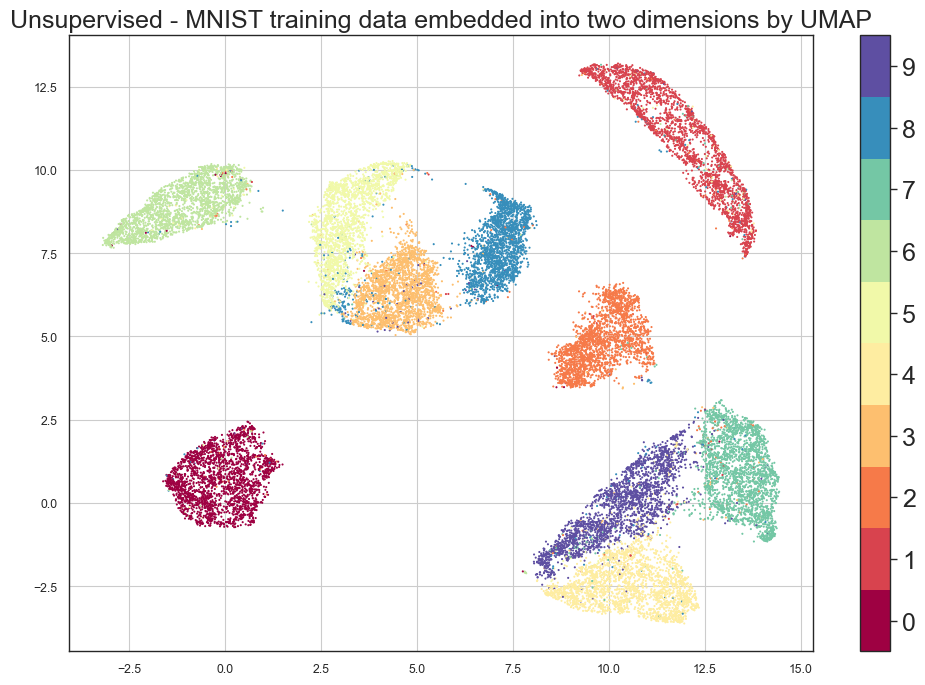

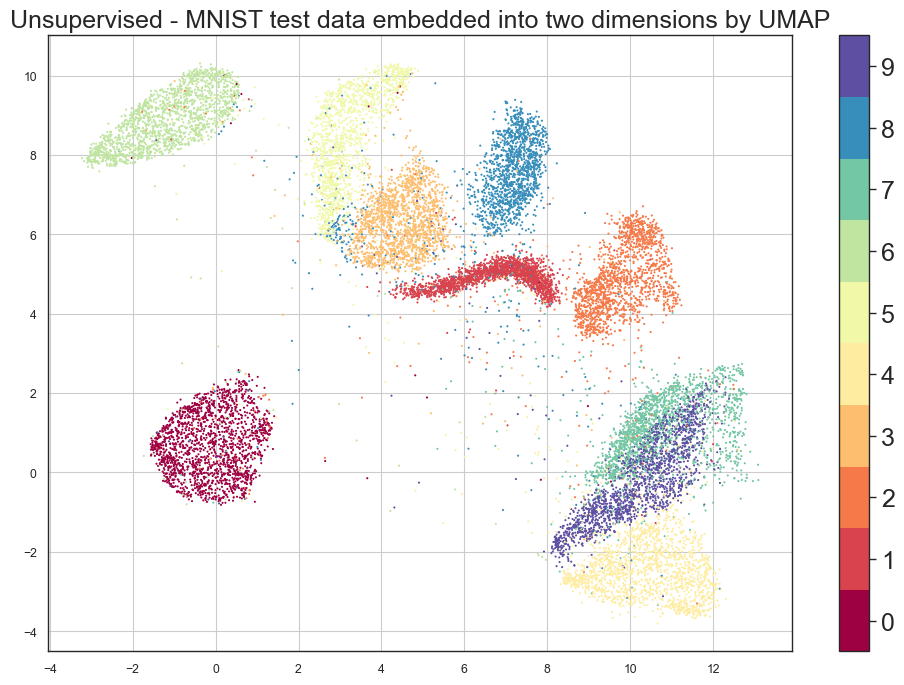

In [76]:
fig, ax = plt.subplots(figsize=(12, 8)) 
color = Y_train.astype(int) 
plt.scatter(embedding_u0[:, 0], embedding_u0[:, 1], c=color, cmap="Spectral", s=0.5)
ax.grid(True)
cbar.set_ticks(np.arange(10))
plt.title("Unsupervised - MNIST training data embedded into two dimensions by UMAP", fontsize=18)
cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.ax.tick_params(labelsize=18)
cbar.set_ticklabels(classes)
plt.show()
          
fig, ax = plt.subplots(figsize=(12, 8)) 
color = Y_test.astype(int)
plt.scatter(embedding_u1[:, 0], embedding_u1[:, 1], c=color, cmap="Spectral", s=0.5)
ax.grid(True)
cbar.set_ticks(np.arange(10))
plt.title("Unsupervised - MNIST test data embedded into two dimensions by UMAP", fontsize=18)
cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.ax.tick_params(labelsize=18)
cbar.set_ticklabels(classes)
plt.show()

### Even though the Test data was embedded in 2D clusters, there are many outliers and the clusters aren't in the same places or as tightly grouped together as the training data. There is a lot of overlap.

UMAP can be used as an effective preprocessing step to boost the performance of density based clustering. This is somewhat controversial, and should be attempted with care. For a good discussion of some of the issues involved in this please see the various answers in this stackoverflow thread (https://stats.stackexchange.com/questions/263539/clustering-on-the-output-of-t-sne) on clustering the results of t-SNE. Many of the points of concern raised there are salient for clustering the results of UMAP. The most notable is that UMAP, like t-SNE, does not completely preserve density. UMAP, like t-SNE, can also create tears in clusters that are not actually present, resulting in a finer clustering than is necessarily present in the data. Despite these concerns there are still valid reasons to use UMAP as a preprocessing step for clustering. As with any clustering approach one will want to do some exploration and evaluation of the clusters that come out to try to validate them if possible.

With all of that said, let’s work through an example to demonstrate the difficulties that can face clustering approaches and how UMAP can provide a powerful tool to help overcome them.

<span style="color:blue"> <i> Let's do unsupervised learning and identify distinct classes with the help of UMAP: </i></span> <br>

(1) First, reduce the data to 2-dimensions using UMAP. Do unsupervised learning on the training data. Choose "n_neighbors=30,min_dist=0.0,random_state=42"

For clustering, try HDBSCAN, which we believe to be among the most advanced density based tehcniques.

(2) Create the HDBSCAN model (You can change the hyperparameter setting):

&nbsp; **HDBSCAN_model = hdbscan.HDBSCAN(min_samples=10,min_cluster_size=100)**

(3) Take the embedding you created in (1) and get predicted classes using "fit_predict"

&nbsp; **HDBSCAN_labels = HDBSCAN_model.fit_predict(embedding)**

(4) Predicted label = -1 means that HDBSCAN refused to cluster that points and classify the as “noise.” Make the scatterplot in 2d using umap embedding and color points according to the cluster membership. Color noise as gray.

In [7]:
import hdbscan

In [78]:
model = umap.UMAP(n_neighbors=30,min_dist=0.0) 
embedding = model.fit_transform(X_train)

In [79]:
HDBSCAN_model = hdbscan.HDBSCAN(min_samples=10,min_cluster_size=100) 
HDBSCAN_labels = HDBSCAN_model.fit_predict(embedding)

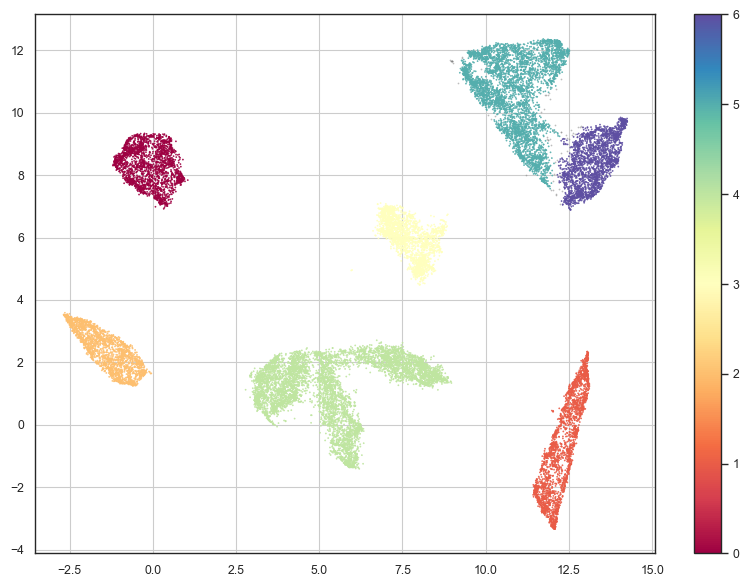

In [85]:
clustered = (HDBSCAN_labels >= 0) 
plt.figure(figsize=(10,7))
plt.scatter(embedding[~clustered, 0], embedding[~clustered, 1], 
            c=(0.5, 0.5, 0.5), s=0.2, alpha=0.5)
plt.scatter(embedding[clustered, 0], embedding[clustered, 1], 
            c=HDBSCAN_labels[clustered], s=0.2, cmap='Spectral')
plt.colorbar()
plt.grid()

<span style="color:blue"> <i> Evaluate the adjusted Rand score (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html) and adjusted mutual information (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_mutual_info_score.html) for this clustering as compared with the true labels. </i></span> <br>

(Note: Changing the hyperparameters of UMAP/HDBSCAN model and increasing the total number of sample can improve those scores.)

In [154]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

In [155]:
print("adjusted Rand score: ", adjusted_rand_score(HDBSCAN_labels, Y_train))
print("adjusted mutual information: ", adjusted_mutual_info_score(HDBSCAN_labels, Y_train))


adjusted Rand score:  0.6428883537974192
adjusted mutual information:  0.8041940955866437


***